# Análisis de los datos

In [21]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Se presenta un análisis detallado de las variables regresoras que serán empleadas para el modelo que predice el FRP de un incendio dada una latitud y longitud, así como las correlaciones entre ellas y con la variable objetivo

### **Caracteristicas de las variables**

In [22]:
# l_f = []
# for k in [2022, 2023,2024, 2025]:
#     print(f"Analizando el año {k}:")
#     dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/Modelo_Incendios_{k}.parquet", type="df")
#     l_f.append(dataf)
# dataFrame = pd.concat(l_f, ignore_index=True)

dataFrame = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/MI.parquet", type="df")

Dataframe MI.parquet importado correctamente


In [23]:
df_final = dataFrame.copy()

**COMPOSICIÓN DEL DATASET**

Las variables son:

In [24]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 2026 non-null   float64       
 1   lon                 2026 non-null   float64       
 2   frp_mean            2026 non-null   float64       
 3   date                2026 non-null   datetime64[us]
 4   elevacion_centro    2026 non-null   float64       
 5   grados              2026 non-null   float64       
 6   porcentaje          2026 non-null   float64       
 7   temp_mean           2026 non-null   float64       
 8   temp_max            2026 non-null   float64       
 9   temp_min            2026 non-null   float64       
 10  humidity_mean       2026 non-null   float64       
 11  precipitation       2026 non-null   float64       
 12  wind_speed_max      2026 non-null   float64       
 13  wind_gusts_max      2026 non-null   float64       
 14  pre

Total de incendios:

In [25]:
print(f"Total: {len(df_final)} incendios")

Total: 2026 incendios


Representación primeras filas del dataset:

In [26]:
print(df_final.head(10))

         lat        lon    frp_mean       date  elevacion_centro     grados  \
0  43.219070  -6.655960  146.240000 2022-01-01       1012.903931  28.050967   
1  36.876417   6.951603   65.496667 2022-01-04          4.535087   0.277444   
2  45.191311  29.577375  101.732000 2022-01-05          0.505476   0.302184   
3  37.850200  22.449520   63.520000 2022-01-06        604.561340   3.747100   
4  41.642350  -6.436230   72.490000 2022-01-15        721.111511  13.753480   
5  44.986833  29.564723   82.397333 2022-01-21          0.340551   0.175570   
6  44.165150   3.618980   63.350000 2022-01-26        956.908752  17.495062   
7  42.237090  -6.222850   55.420000 2022-01-26       1208.549438   1.948171   
8  40.413691  -7.480300  158.089147 2022-01-27        743.457153   4.475302   
9  41.966776  -6.833300   95.647941 2022-01-28       1123.853516  12.291173   

   porcentaje  temp_mean  temp_max  temp_min  ...  wind_gusts_max  \
0   53.285100       11.5      14.6       8.6  ...            

**VARIABLE OBJETIVO**

La varible objetivo es una variable numérica continua. 

Esta variable es el frp_mean, y representa la potencia radiactiva del fuego, medida como la energía liberada por unidad de tiempo (MW)

In [27]:
print(df_final['frp_mean'])

0       146.240000
1        65.496667
2       101.732000
3        63.520000
4        72.490000
           ...    
2021     72.216667
2022     63.700000
2023     56.440000
2024    114.770000
2025     80.790000
Name: frp_mean, Length: 2026, dtype: float64


**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Eliminamos latitud y longitud, ya que se hizo un análisis en el notebook para el problema 1, en el que se observan las zonas de incendio.

Además, estas variables no serán empleadas en el modelo.

In [28]:
df = df_final.drop(columns = ['lat', 'lon'])
df.describe()

,frp_mean,date,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,...,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ,soil_temp
count,2026.000000,2026,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,...,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,88.459182,2024-01-16 04:59:56.446199,424.696476,8.058098,14.643384,21.556614,27.980207,15.408144,48.776900,0.175864,...,41.595953,968.473741,21.142646,23.021392,5.638332,43948.547206,0.404280,-0.439046,28.493077,22.564042
min,50.090000,2022-01-01 00:00:00,-4.045881,0.001912,0.003337,-4.600000,-0.400000,-9.100000,9.000000,0.000000,...,14.000000,718.400000,0.000000,3.560000,0.440000,0.000000,-0.335687,-0.844250,0.073528,-4.010000
25%,61.302500,2022-08-17 00:00:00,113.903854,1.230652,2.148224,16.600000,22.500000,10.600000,38.000000,0.000000,...,32.400000,944.025000,1.000000,19.817500,4.000000,40466.437500,0.230289,-0.562344,3.555425,16.842500
50%,76.353684,2024-03-10 00:00:00,276.835129,5.297527,9.272366,24.100000,30.200000,17.700000,48.000000,0.000000,...,40.000000,982.700000,12.000000,24.655000,5.890000,45965.980000,0.379981,-0.435744,6.487014,25.810000
75%,102.570000,2025-05-17 12:00:00,634.575027,12.699013,22.534169,27.900000,34.500000,21.400000,59.000000,0.000000,...,48.600000,1001.775000,34.000000,27.460000,7.170000,48098.370000,0.567330,-0.337249,11.491541,29.790000
max,607.340000,2025-12-29 00:00:00,2908.075684,58.684683,164.372099,39.000000,48.000000,33.500000,93.000000,20.100000,...,106.200000,1039.000000,100.000000,31.270000,12.360000,68808.280000,0.901769,1.000000,483.097458,38.470000
std,41.699364,NaN,410.182645,8.327092,15.910742,8.657134,9.170685,8.226566,14.978918,0.998658,...,13.168684,44.854258,23.601923,5.554719,2.232889,6383.571473,0.212321,0.171239,75.399202,9.800113


**DISTRIBUCIÓN DE LAS VARIABLES**

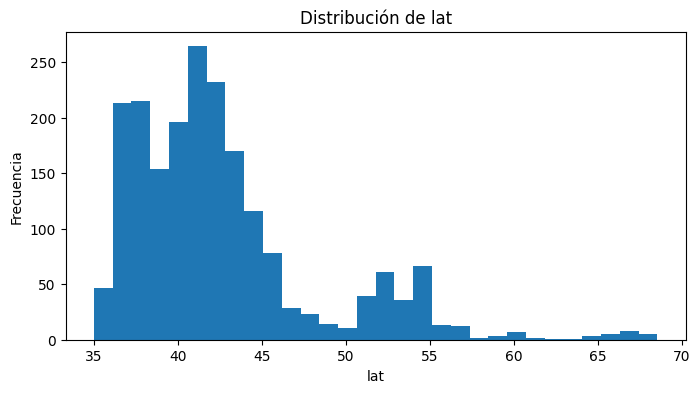

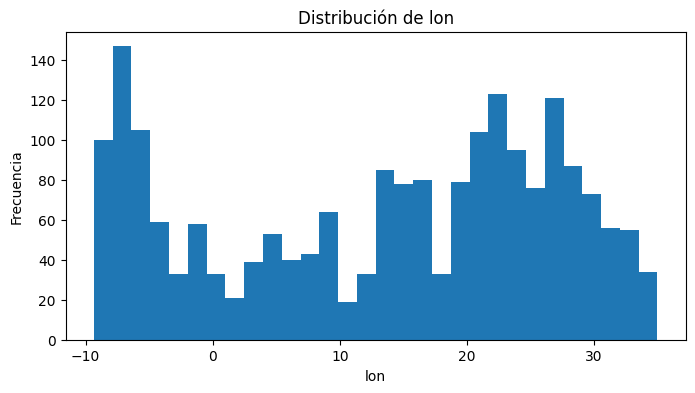

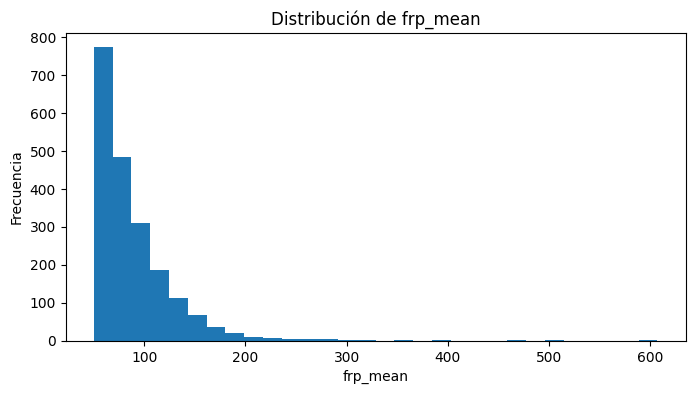

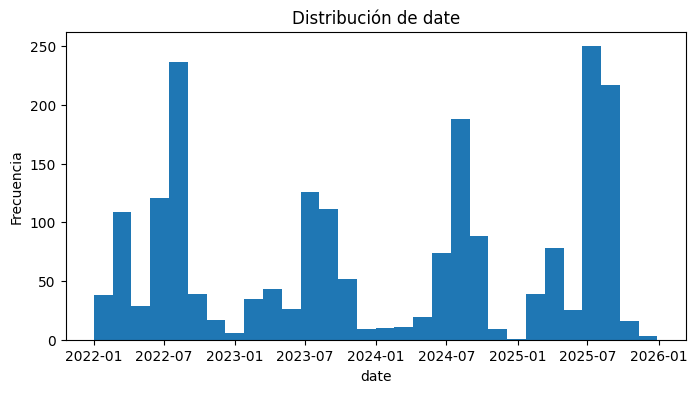

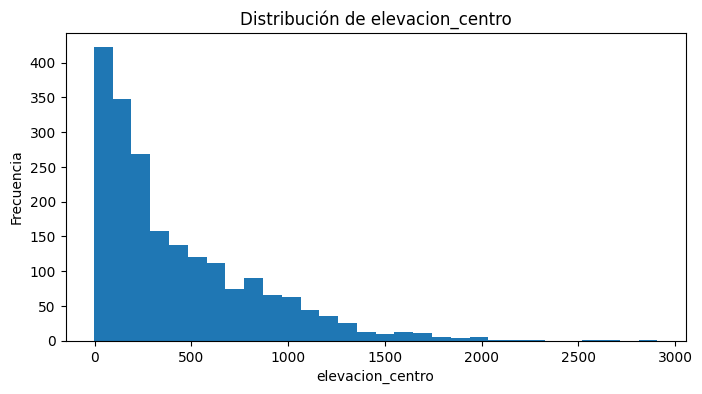

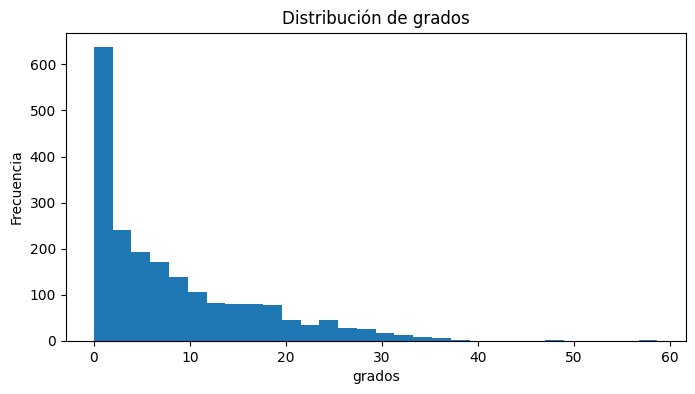

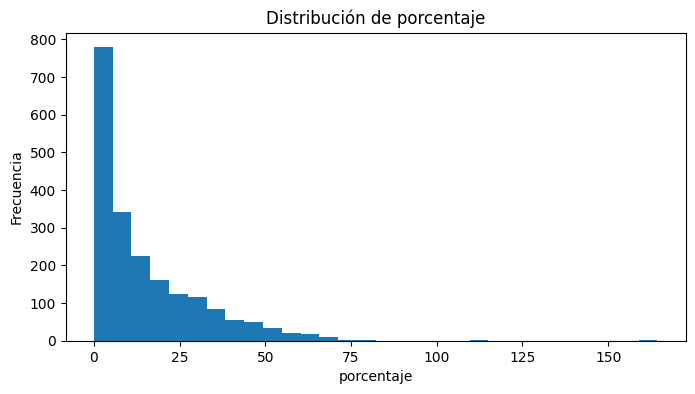

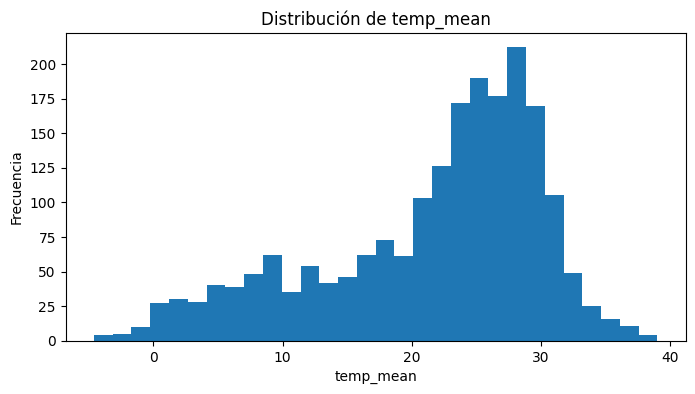

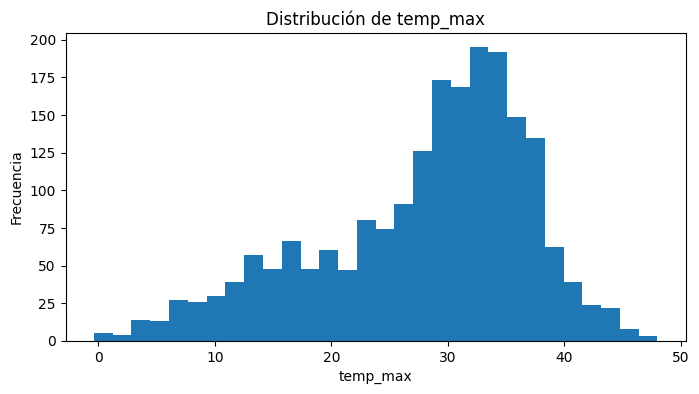

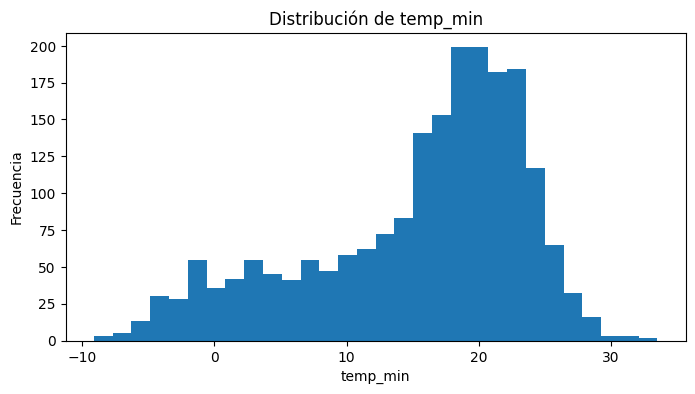

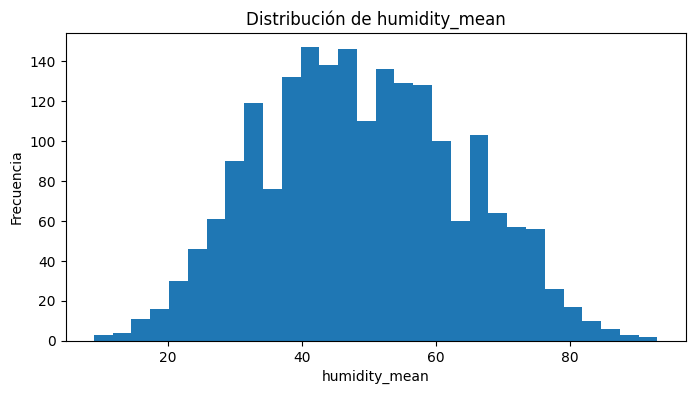

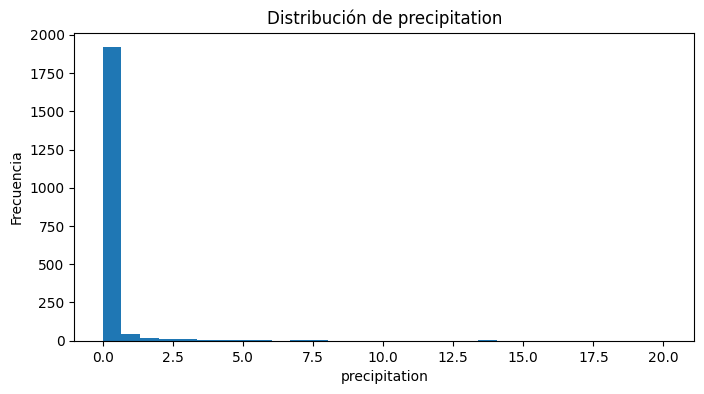

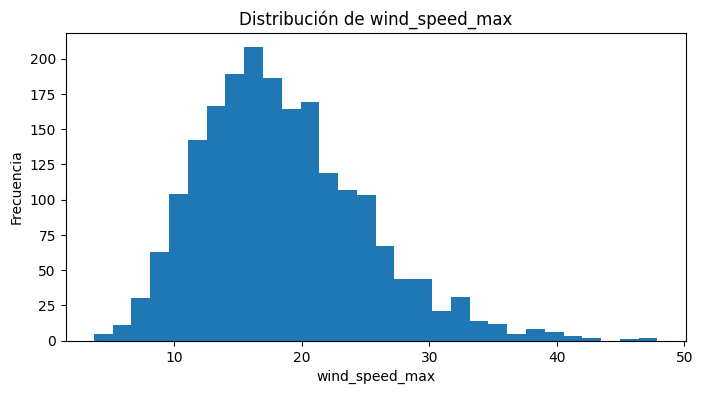

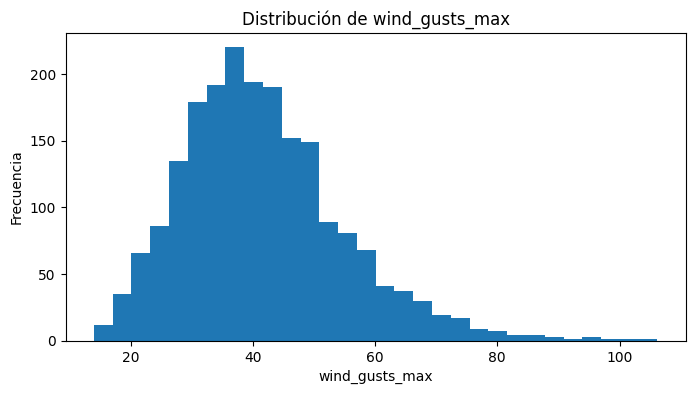

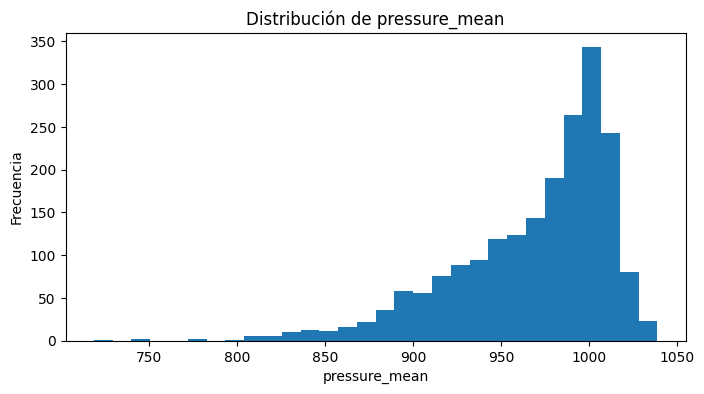

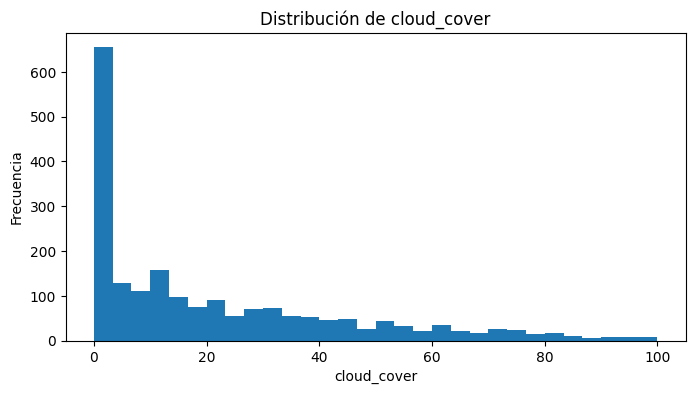

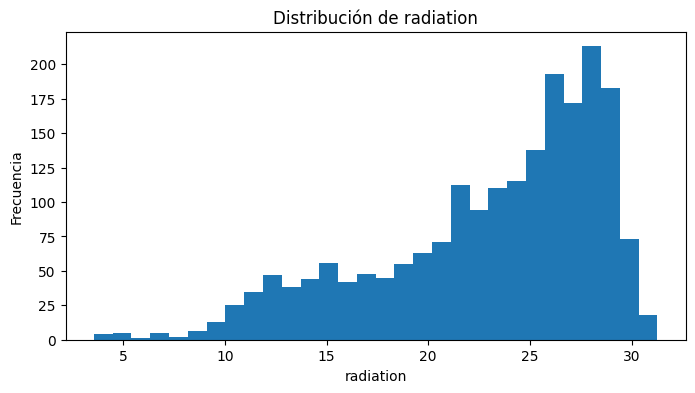

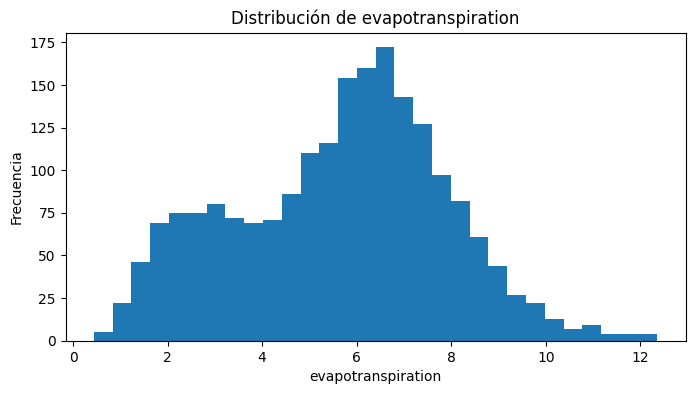

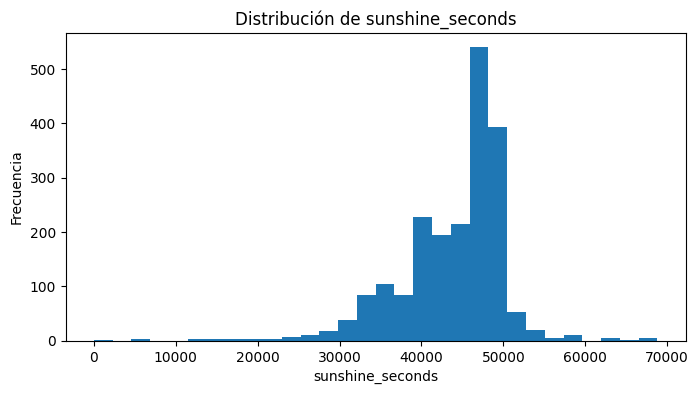

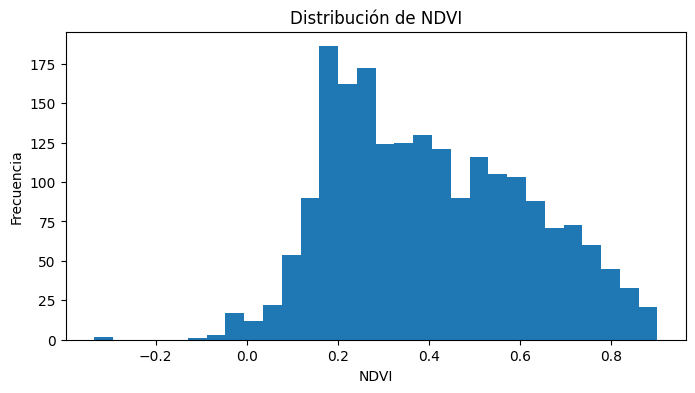

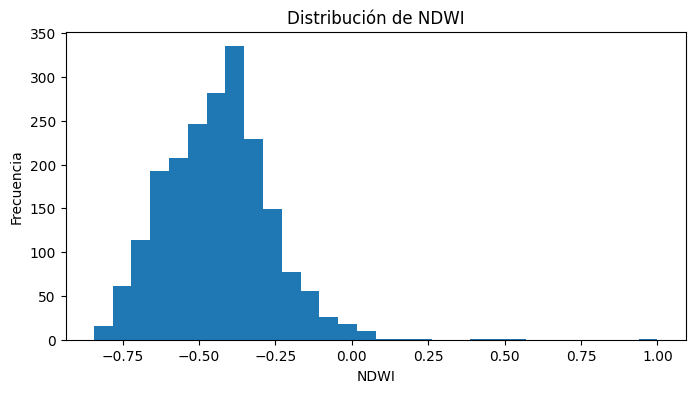

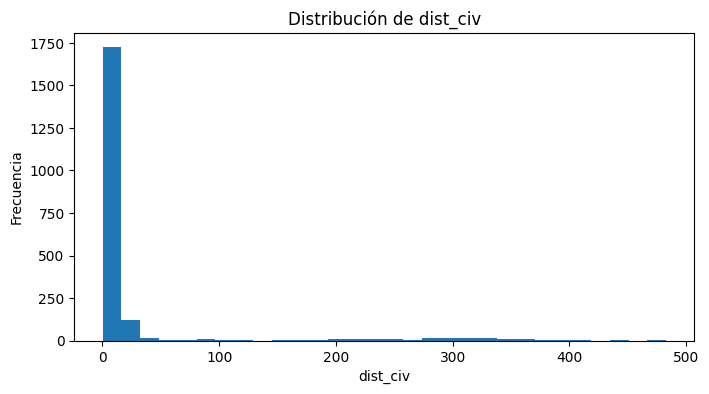

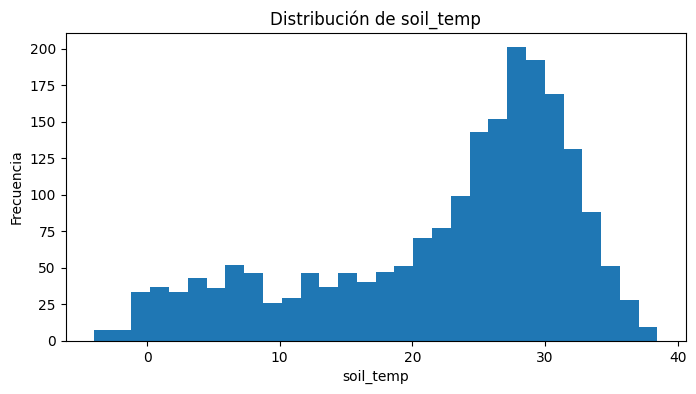

In [29]:
for col in df_final.columns:
    plt.figure(figsize=(8, 4))
    df_final[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

Se observa que la variable objetivo tiene muchas observaciones con valores altos, y solo algunas con valores bajos. 

Se debe tener en cuenta porque hay modelos que no son robustos a la presencia de outliers.

**ANÁLISIS DE LA PRESENCIA DE OUTLIERS**

Solo se realiza el estudio de outliers para frp porque para el resto de variables fue realizado en el notebook del problema 1.

In [30]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in ['frp_mean']:
    outliers, limite_inf, limite_sup = detectar_outliers(df_final, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable frp_mean: Detectados 87 outliers (fuera del rango -0.60 - 164.47) 



Hacemos un análisis de dónde tenemos esos outliers. Para ello usaremos el df general, para poder dibujar el mapa de Europa:

In [31]:
dataFrame_general = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/MINI.parquet", type="df")

Dataframe MINI.parquet importado correctamente


**1. Outliers en frp_mean (variable objetivo):**

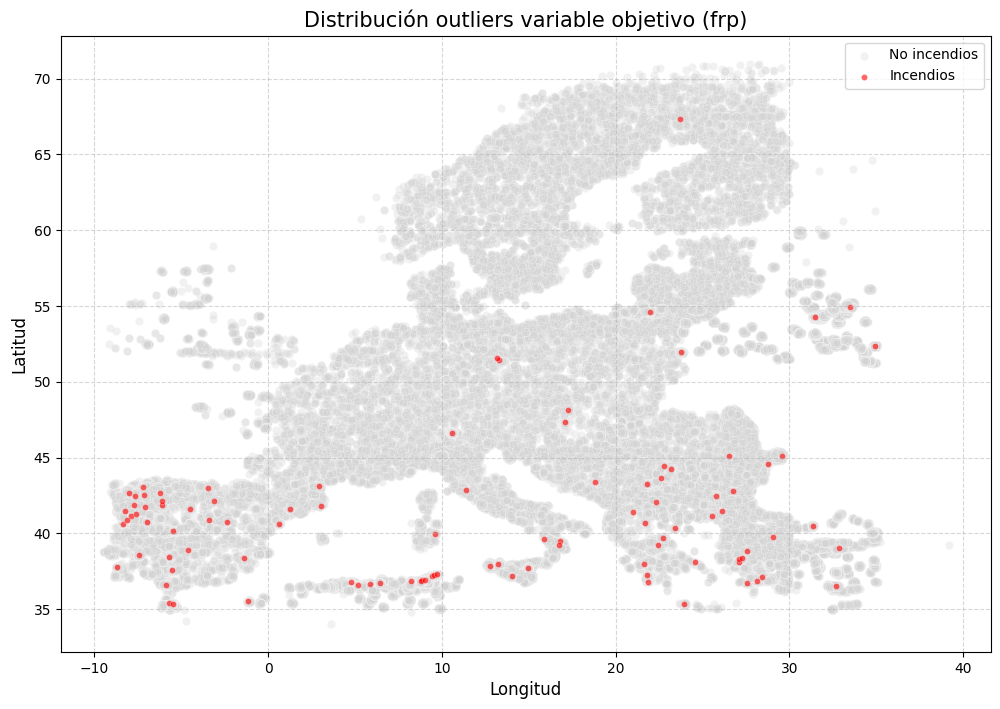

In [32]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['frp_mean'] > 160.09]
datos_no_inc = dataFrame_general[dataFrame_general['final'] == 0]

sns.scatterplot(data=datos_no_inc, x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_dist, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución outliers variable objetivo (frp)', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Los outliers detectados son completamente normales. La mayoría se encuentran en las zonas de Galicia y norte de Portugal, así como en Sicilia y el norte de África. Propios de la región Mediterránea y Estépica.

**CORRELACIONES ENTRE LAS VARIABLES REGRESORAS**

Posteriormente, se realizará un análisis de las correlaciones con la variable objetivo.

In [33]:
df2 = df_final.drop(columns = ['frp_mean', 'date'])
df2.corr().style.background_gradient(cmap='coolwarm')

,lat,lon,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI,dist_civ,soil_temp
lat,1.000000,0.237331,-0.294617,-0.331200,-0.315383,-0.478661,-0.478282,-0.496580,0.395215,0.073097,-0.153255,-0.275584,0.328409,0.293083,-0.318587,-0.451694,0.008805,-0.106543,0.148973,-0.283617,-0.542027
lon,0.237331,1.000000,-0.240097,-0.248058,-0.238809,-0.146871,-0.161474,-0.140041,0.122658,-0.007770,-0.034838,-0.106503,0.232973,-0.077596,-0.153483,-0.155763,-0.043165,-0.165355,0.130526,-0.132457,-0.145514
elevacion_centro,-0.294617,-0.240097,1.000000,0.463045,0.451601,-0.060959,-0.039774,-0.080963,-0.198891,0.006111,-0.239367,0.024423,-0.991267,-0.030458,0.060126,-0.021805,-0.040972,0.141732,-0.123673,0.120478,0.032184
grados,-0.331200,-0.248058,0.463045,1.000000,0.995707,0.130848,0.120523,0.149778,-0.147707,0.003733,-0.063164,0.207226,-0.482097,-0.064321,0.117483,0.112436,0.010831,0.316822,-0.248251,0.168376,0.192628
porcentaje,-0.315383,-0.238809,0.451601,0.995707,1.000000,0.121636,0.110752,0.140662,-0.138171,0.006408,-0.065349,0.199443,-0.470398,-0.060175,0.111067,0.103296,0.010134,0.303742,-0.235576,0.160240,0.181978
temp_mean,-0.478661,-0.146871,-0.060959,0.130848,0.121636,1.000000,0.983870,0.977800,-0.606336,-0.045080,0.199552,0.233619,-0.004858,-0.266910,0.732751,0.889584,0.586579,0.268617,-0.316848,0.202544,0.961034
temp_max,-0.478282,-0.161474,-0.039774,0.120523,0.110752,0.983870,1.000000,0.934268,-0.633075,-0.068002,0.151738,0.184076,-0.022947,-0.287588,0.722892,0.880339,0.575061,0.264653,-0.315027,0.232790,0.932490
temp_min,-0.496580,-0.140041,-0.080963,0.149778,0.140662,0.977800,0.934268,1.000000,-0.539213,-0.010822,0.264503,0.302672,0.013806,-0.230944,0.685808,0.858364,0.537281,0.266934,-0.311763,0.184422,0.956393
humidity_mean,0.395215,0.122658,-0.198891,-0.147707,-0.138171,-0.606336,-0.633075,-0.539213,1.000000,0.202548,-0.136677,-0.204363,0.223452,0.330253,-0.532251,-0.737765,-0.371664,-0.137935,0.156192,-0.224819,-0.536667
precipitation,0.073097,-0.007770,0.006111,0.003733,0.006408,-0.045080,-0.068002,-0.010822,0.202548,1.000000,0.046040,0.054431,-0.016611,0.244440,-0.142912,-0.127781,-0.149470,0.034692,-0.012212,-0.034589,-0.025637


<Axes: >

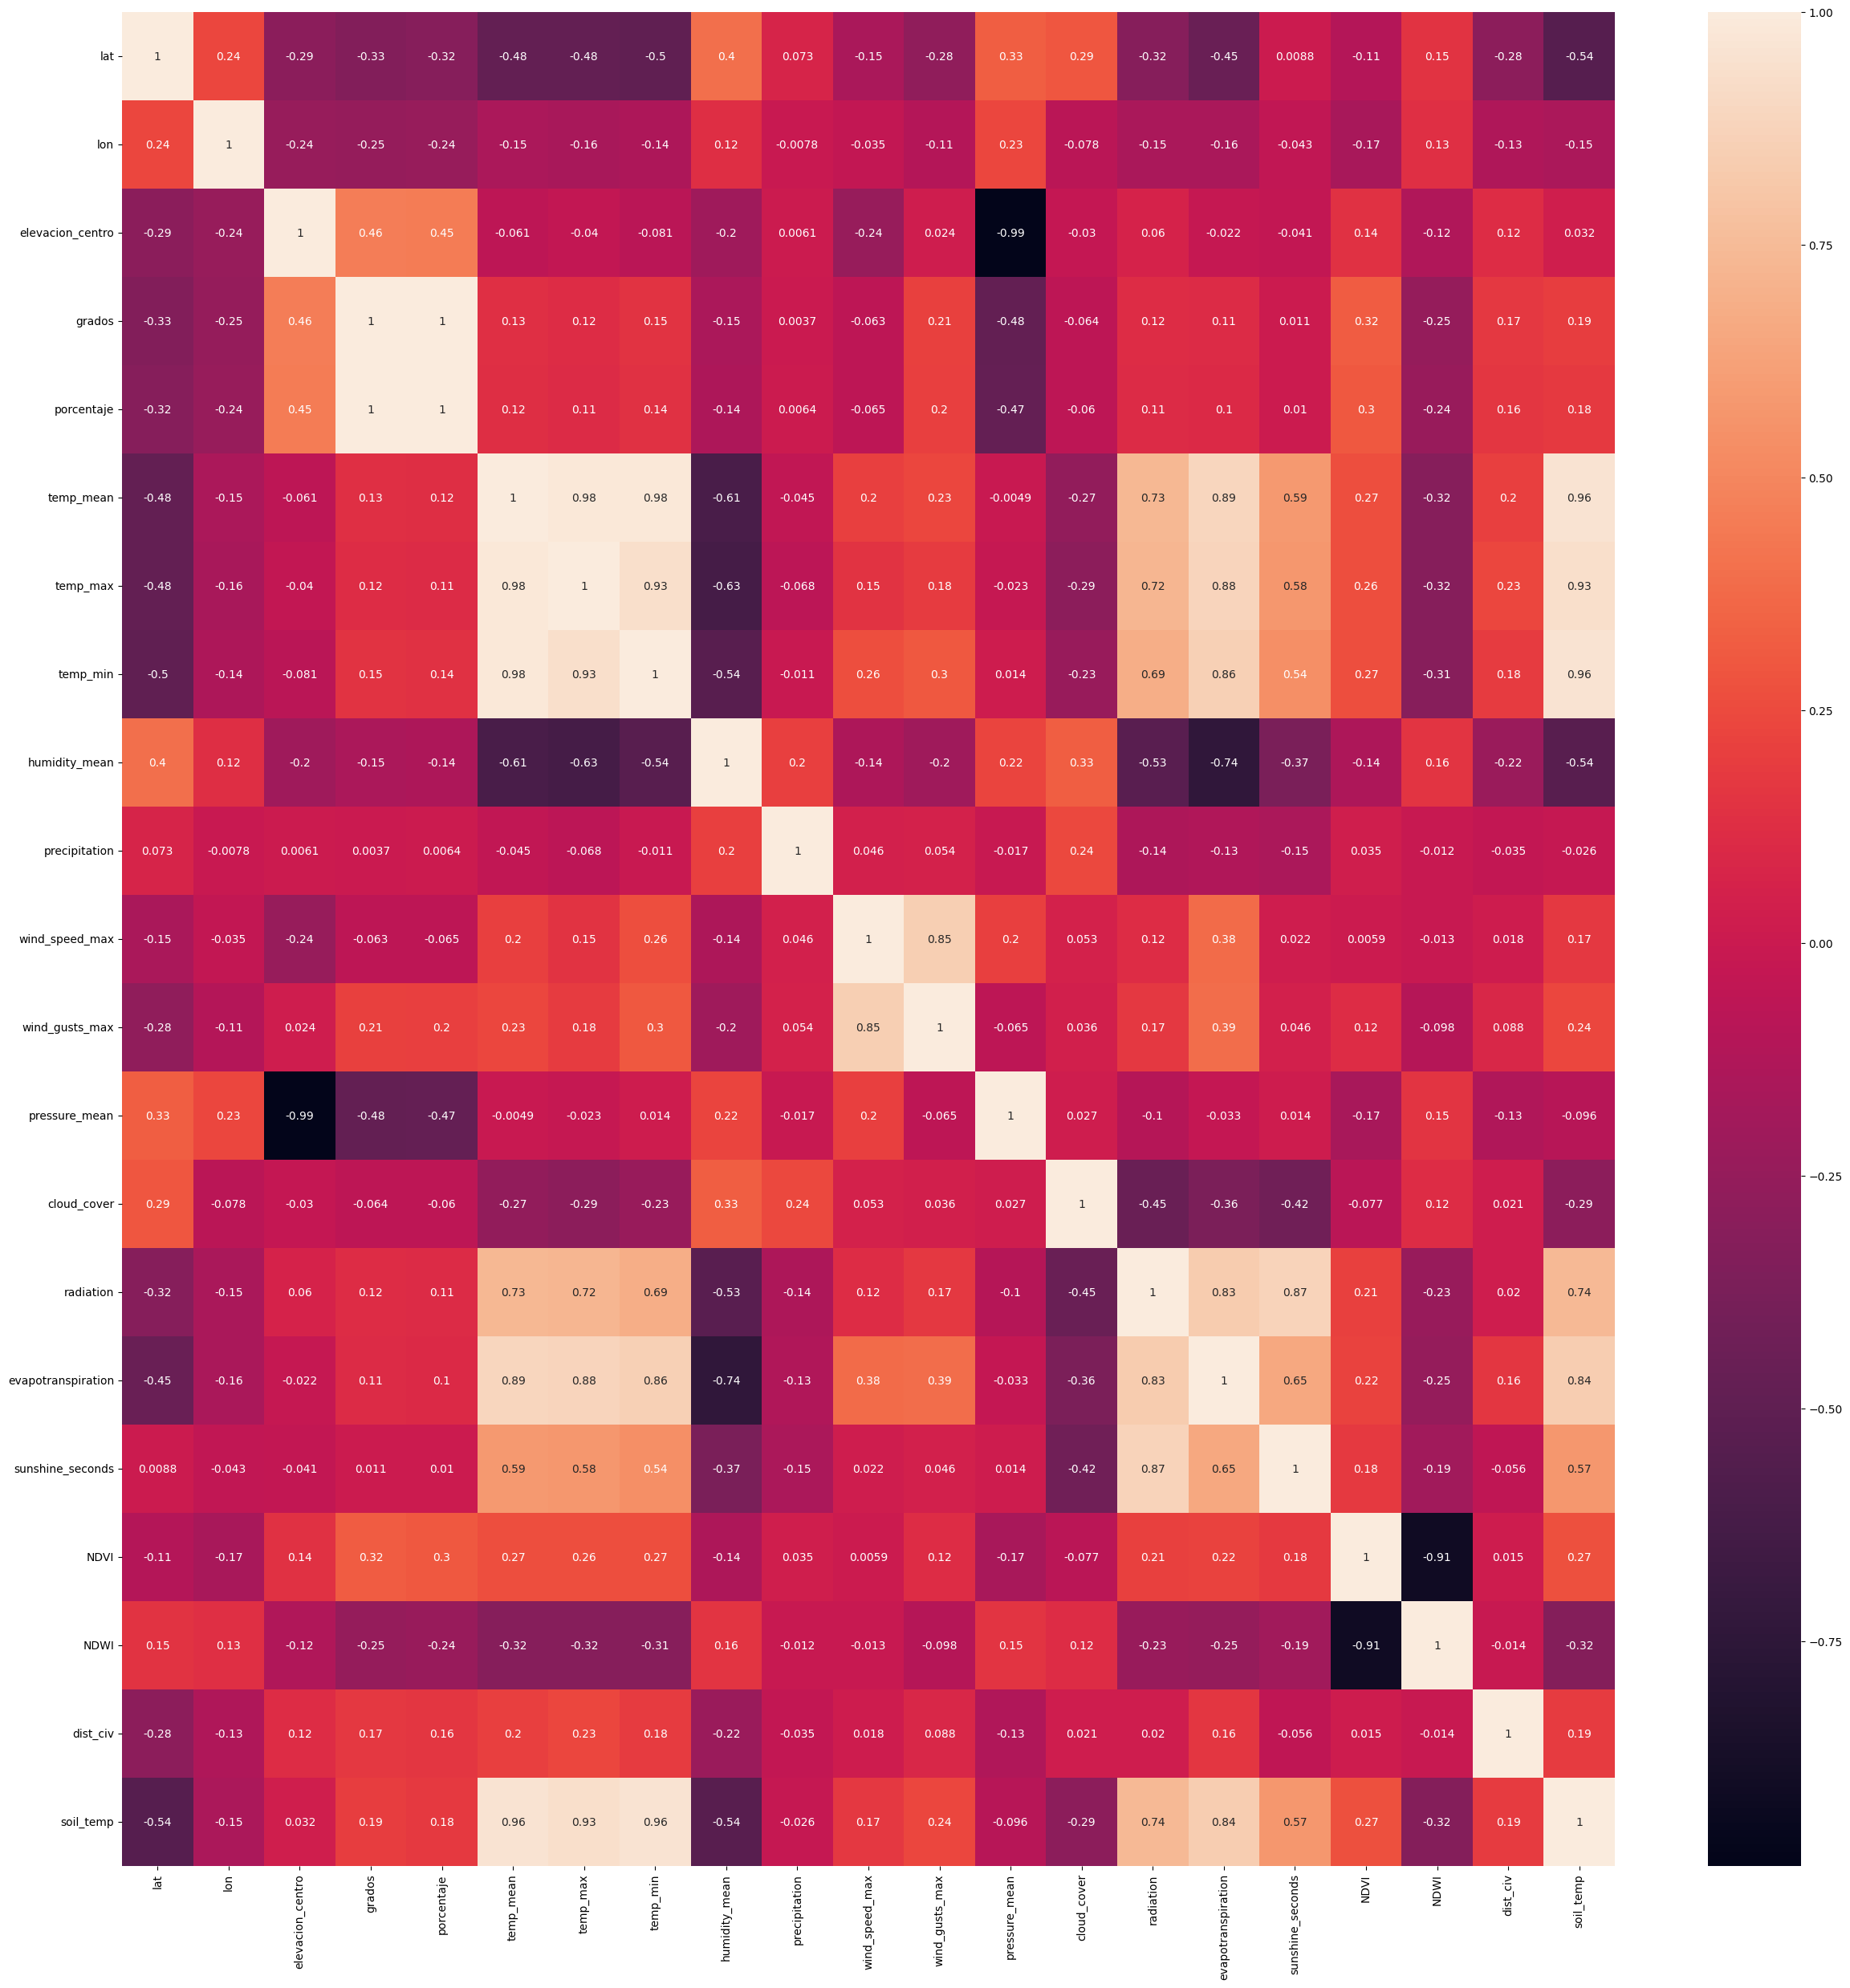

In [34]:
plt.figure(figsize=(30, 30))
sns.heatmap(df2.corr(), annot=True)

**Conclusiones:**

Las correlaciones han cambiado ligeramente con respecto al análisis realizado para el problema uno. Esto se debe a que el tamaño del dataset es menor, por lo que las correlaciones entre variables no se capturan completamente.

Aún así, se observa que hay muchas variables correlacionadas. Destacan:
1. **grados y porcentaje**, con una **correlación de 1**.
2. Las variables que representan la temperatura (**temp_max, temp_min y temp_mean**), con una correlación casi **cercana a 1**.
3. **pressure_mean y elevacion_centro**, con correlación negativa (**-0.99**).
4. **NDVI y NDWI**, con correlación negativa (valor **-0.91**).
5. La correlación de **evapotranspiration y radiation** (con valor **0.83**).
6. La correlación de **radiation con sunshine_seconds** (con valor **0.87**).
7. La correlación de **wind_speed_max y wind_gusts_max**, con una correlación de **0.85**. 
8. **evapotranspiration con temp_mean y temp_max** (con una correlación aproximada de **0.89**). Y de **0.86** con **temp_min**.
9. **evapotranspiration con humidity_mean** (valor **-0.74**).


La variable evapotranspiration, por tanto, es la que más correlacionada está con el resto de variables. 

También sería importante seleccionar una entre grados o porcentaje, ya que representan lo mismo, entre NDVI y NDWI, entre pressure_mean y elevacion_centro, y una entre todas las variables que representan la temperatura. 

El resto de correlaciones son menores a 0.7.

**CORRELACIÓN DE LAS VARIABLES REGRESORAS CON LA VARIABLE OBJETIVO**

In [35]:
df_final_corr = df_final.drop(columns = ['date'])
correlaciones = df_final_corr.corr()
corr_objetivo = correlaciones['frp_mean'].drop(labels=['frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
wind_gusts_max,0.148348
NDVI,0.148169
evapotranspiration,0.143393
grados,0.134577
soil_temp,0.132029
porcentaje,0.130122
temp_max,0.125625
temp_mean,0.123307
temp_min,0.118279
wind_speed_max,0.110300


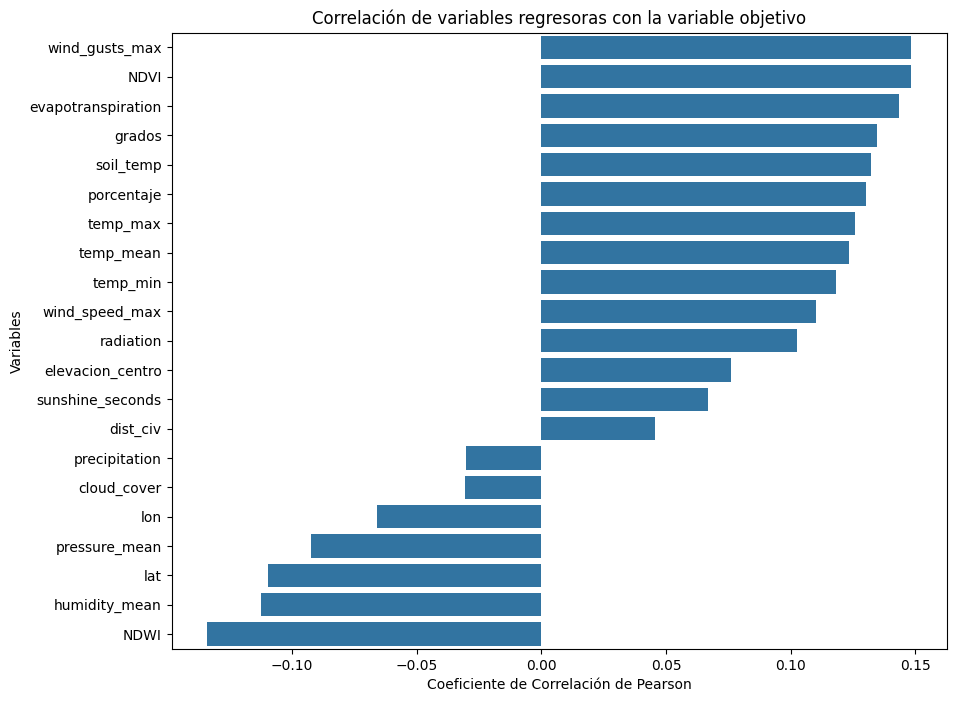

In [36]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

**Conclusión:**

Se observa que las variables más correlacionadas con la variable objetivo son wind_gusts_max, evapotranspiration, grados, porcentaje, NDVI, las variables de temperatura, y NDWI y humidity_mean, con correlación negativa. 

Aún así, las correlaciones son bajas, puesto que ninguna representa un correlación mayor que 0.15. Esto es un indicio de que no existe relación lineal entre la variable objetivo y las variables regresoras. Podría ser problemático plantear un modelo de regresión lineal, puesto que este no conseguiría capturar realmente patrones. 

Por ejemplo, el posible que la temperatura no afecte al FRP de forma lineal, sino que a partir de ciertos grados el riesgo se dispare exponencialmente. O incluso que una variable por sí sola no influya directamente en el frp, sino que esta influencia se vea incrementada con la interacción con otras variables.

**CORRELACIÓN MES CON FRP**

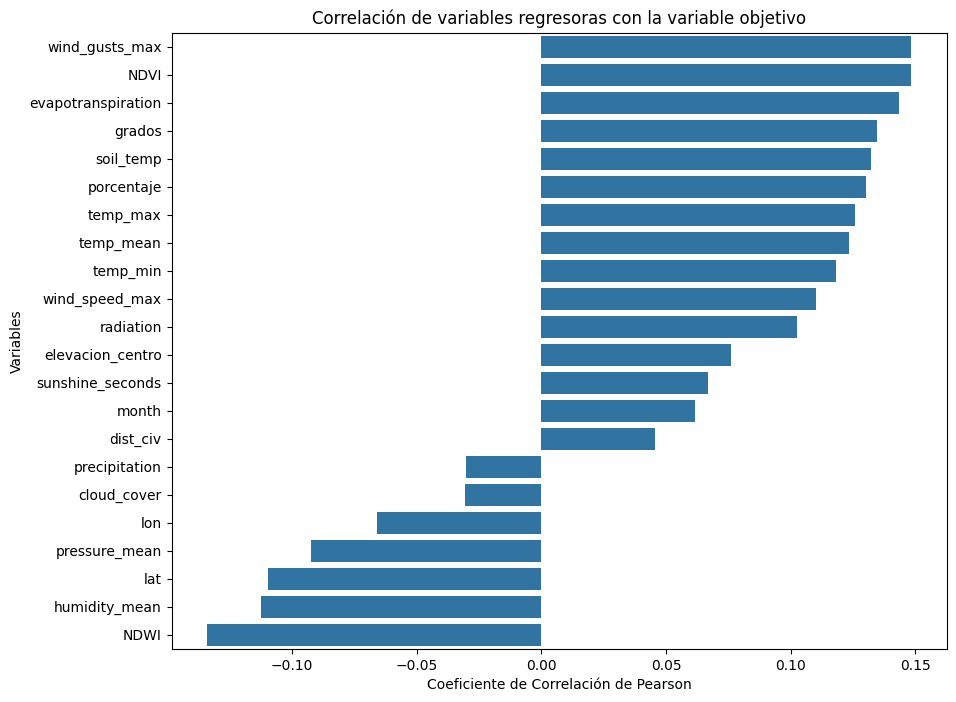

,Coeficiente de correlación
wind_gusts_max,0.148348
NDVI,0.148169
evapotranspiration,0.143393
grados,0.134577
soil_temp,0.132029
porcentaje,0.130122
temp_max,0.125625
temp_mean,0.123307
temp_min,0.118279
wind_speed_max,0.110300


In [37]:
df_final_corr2 = df_final.copy()
df_final_corr2['month'] = df_final['date'].dt.month
df_final_corr2['month'] = df_final_corr2['month'].astype('category')

df_sin_date = df_final_corr2.drop(columns = ['date'])
correlaciones = df_sin_date.corr()
corr_objetivo = correlaciones['frp_mean'].drop(labels=['frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

df_corr_final

**CORRELACIÓN DE LAS VARIABLES CON LA ESCALA LOGARÍTMICA DEL OBJETIVO**

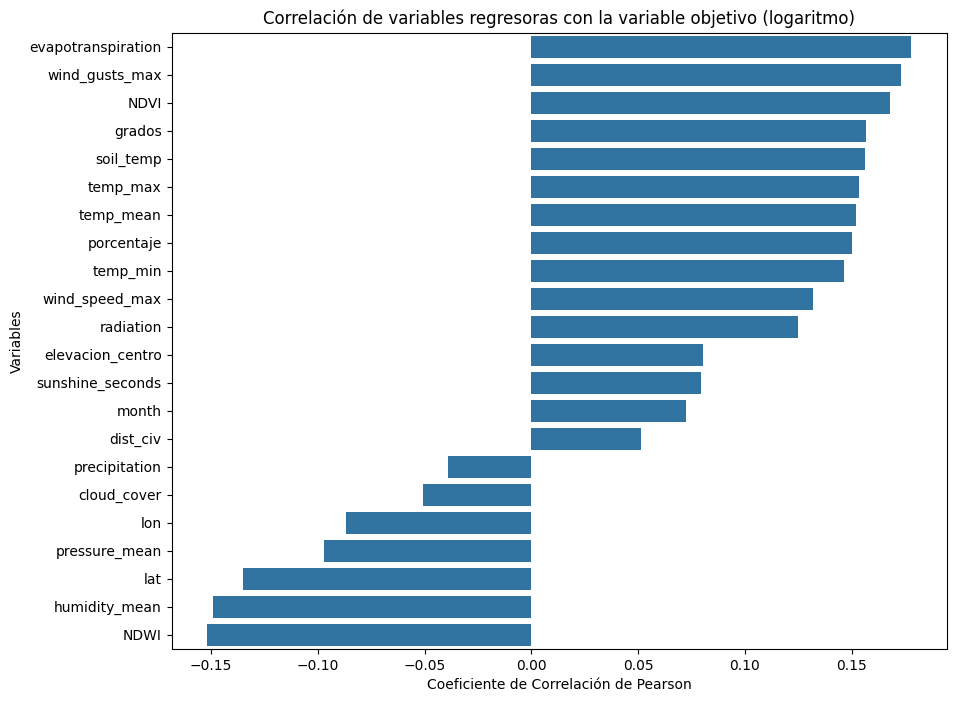

,Coeficiente de correlación
evapotranspiration,0.177994
wind_gusts_max,0.172946
NDVI,0.167985
grados,0.156552
soil_temp,0.156111
temp_max,0.153375
temp_mean,0.151943
porcentaje,0.150340
temp_min,0.146538
wind_speed_max,0.131984


In [38]:
df_final_corr2['log_frp'] = np.log1p(df_final_corr2['frp_mean'])

df_sin_date = df_final_corr2.drop(columns = ['date'])
correlaciones = df_sin_date.corr()
corr_objetivo = correlaciones['log_frp'].drop(labels=['log_frp', 'frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo (logaritmo)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

df_corr_final

Se observa que las correlaciones suben ligeramente, pero vamos consideramos buena idea emplear el logaritmo en lugar del frp_mean para el modelo.

**AÑADIR POSIBLES NUEVAS VARIABLES**

In [39]:
def calcular_vpd(temp, rh):
    svp = 610.7 * (10**((7.5 * temp) / (237.3 + temp)))
    vpd = (1 - (rh / 100)) * svp
    return vpd

In [40]:
df_final_corr2['fuel_stress'] = df_final_corr2['NDVI'] - df_final_corr2['NDWI']
df_final_corr2['VPD'] = calcular_vpd(df_final_corr2['temp_mean'], df_final_corr2['humidity_mean'])
df_final_corr2['dry_fuel_index'] = df_final_corr2['NDVI'] / (df_final_corr2['NDWI'] + 1) 

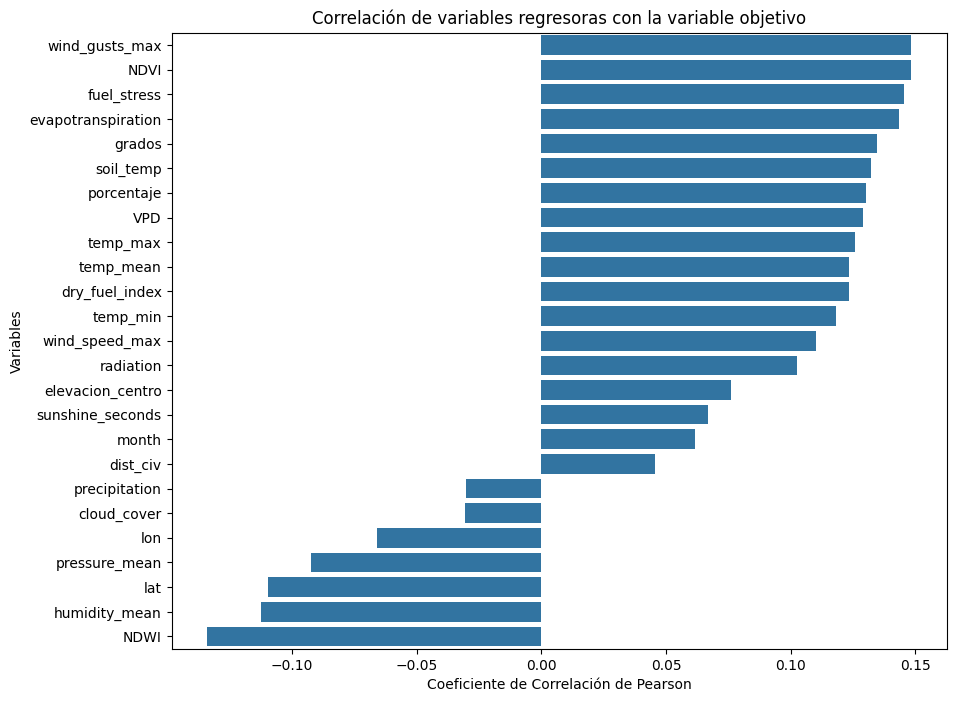

,Coeficiente de correlación
wind_gusts_max,0.148348
NDVI,0.148169
fuel_stress,0.145270
evapotranspiration,0.143393
grados,0.134577
soil_temp,0.132029
porcentaje,0.130122
VPD,0.129163
temp_max,0.125625
temp_mean,0.123307


In [41]:
df_sin_date = df_final_corr2.drop(columns = ['date'])
correlaciones = df_sin_date.corr()
corr_objetivo = correlaciones['frp_mean'].drop(labels=['frp_mean', 'log_frp']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

df_corr_final

**CON EL LOGARITMO**

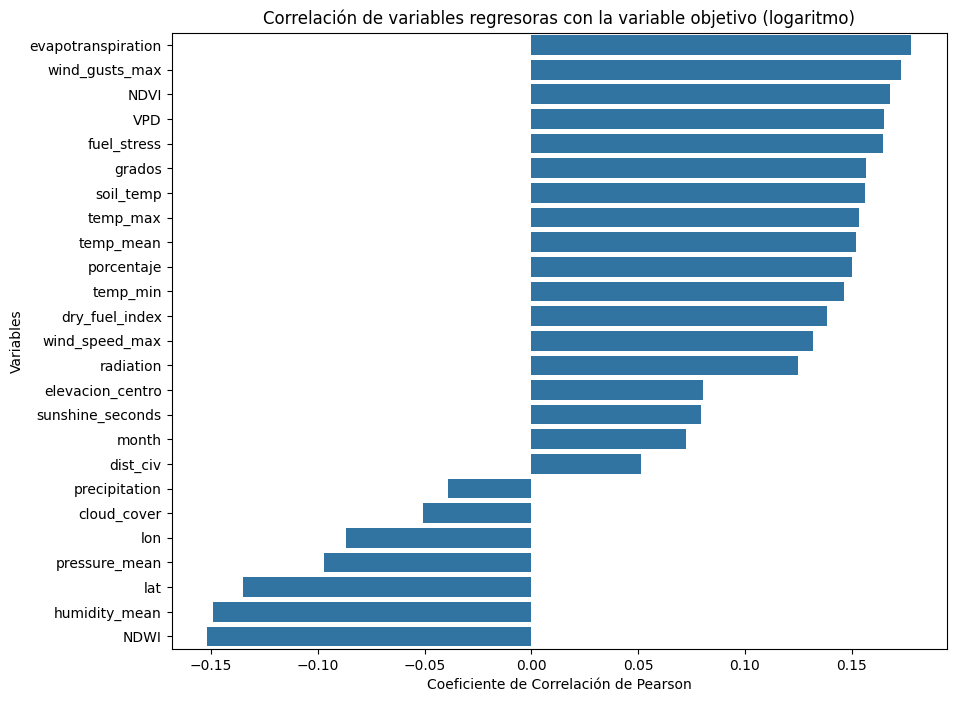

,Coeficiente de correlación
evapotranspiration,0.177994
wind_gusts_max,0.172946
NDVI,0.167985
VPD,0.165375
fuel_stress,0.164600
grados,0.156552
soil_temp,0.156111
temp_max,0.153375
temp_mean,0.151943
porcentaje,0.150340


In [42]:
corr_objetivo = correlaciones['log_frp'].drop(labels=['log_frp', 'frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo (logaritmo)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

df_corr_final

In [43]:
df_final_corr2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lat                 2026 non-null   float64       
 1   lon                 2026 non-null   float64       
 2   frp_mean            2026 non-null   float64       
 3   date                2026 non-null   datetime64[us]
 4   elevacion_centro    2026 non-null   float64       
 5   grados              2026 non-null   float64       
 6   porcentaje          2026 non-null   float64       
 7   temp_mean           2026 non-null   float64       
 8   temp_max            2026 non-null   float64       
 9   temp_min            2026 non-null   float64       
 10  humidity_mean       2026 non-null   float64       
 11  precipitation       2026 non-null   float64       
 12  wind_speed_max      2026 non-null   float64       
 13  wind_gusts_max      2026 non-null   float64       
 14  pre

Se observa que las variables añadidas (VPD, fuel_stress y dry_fuel_index) tienen mayor correlación que muchas de nuestras variables, por lo que consideramos que es buena idea preservarlas.

In [44]:
# mf.subir_fichero(mf.crear_cliente(), "grupo3/cleaned/MI_nuevas.parquet", df_final_corr2)